Workflow for processing Single Images from ingestion till pixel matrix generation.

In [1]:
# Import Libraries
import numpy as np
from PIL import Image
from pathlib import Path
import umap
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import re
from enum import Enum

In [2]:
class Config:
    CONFIG = {
        # Paths
        'paths': {
            'project_root': 'image-processing-workflow',
            'workflow': 'single-image',
            'input_folder': 'input',
            'input_image_folder': 'images',
            'output_folder': 'output',
            'processed_image_folder': 'processed-images',
            'umap_data_folder': 'umap-data',
            'umap_visual_folder': 'umap-visual',
            'led_matrix_folder': 'led-matrix'
        },
        # Prefix
        'prefix': {
            'output_images_prefix': '{original_filename}.jpg',
            'output_images_prefix': '{original_filename}_{folder_name}.jpg',
        },
        # Image Processing
        'image': {
            # 'image_size': (128, 128),
            'image_mode': 'RGB',
            'target_width': 300,
            'jpeg_quality': 100,
            'allowed_extensions': ['.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tiff'],  # Added
            'output_filename': 'output_processed_image.jpg',  # Added
        },
        # UMAP Parameters
        'umap': {
            '2d': {
                'n_components': 2,
                'n_neighbors': 15,
                'min_dist': 1,
                'metric': 'euclidean',
                'random_state': 42
            },
        },
        'led': {
            'matrix_size': 8,
            'brightness': 255,
        },
        'visualization': {
            'plot_umap': True,      # Plot UMAP embeddings
            'preview_matrix': False,  # Preview LED matrix
            'preview_animation': False # Preview animations
        },
    }

In [3]:
# Construct paths and prefixes
project_root = Path(Config.CONFIG['paths']['project_root'])
workflow = Path(Config.CONFIG['paths']['workflow'])
input_folder = Path(Config.CONFIG['paths']['input_folder'])
input_image_folder = Path(Config.CONFIG['paths']['input_image_folder'])
output_folder = Path(Config.CONFIG['paths']['output_folder'])
processed_image_folder = Path(Config.CONFIG['paths']['processed_image_folder'])
umap_data_folder = Path(Config.CONFIG['paths']['umap_data_folder'])
umap_visual_folder = Path(Config.CONFIG['paths']['umap_visual_folder'])

Config.CONFIG['paths']['workflow'] = project_root / workflow
Config.CONFIG['paths']['input_directory'] = input_folder
Config.CONFIG['paths']['input_images'] = input_folder / input_image_folder
Config.CONFIG['paths']['output_directory'] = output_folder
Config.CONFIG['paths']['output_image'] = output_folder / processed_image_folder
Config.CONFIG['paths']['output_umap_data'] = output_folder / umap_data_folder
Config.CONFIG['paths']['output_umap_visual'] = output_folder / umap_visual_folder

def get_output_path(config, folder_key):
    """
    Get the output path for a specific folder from config.
    
    Args:
        config (dict): Configuration dictionary containing paths
        folder_key (str): Key of the folder in config paths (e.g., 'processed_image_folder', 'umap_visual_folder')
    
    Returns:
        Path: Full output path for the specified folder
    """
    return Path(config['paths']['output_directory']) / config['paths'][folder_key]

def get_output_prefix(original_filename, folder_name, extension):
    """
    Generate output filename prefix with folder name.
    
    Args:
        original_filename (str): Original filename without extension
        folder_name (str): Name of the output folder
        extension (str): File extension including dot (e.g., '.jpg', '.png')
    
    Returns:
        str: Formatted output filename
    """
    return f"{original_filename}-{folder_name}{extension}"

In [4]:
class ImageProcessor:
    def __init__(self, config=None):
        self.config = config or Config.CONFIG
        self.output_dir = get_output_path(self.config, 'processed_image_folder')
        self.output_dir.mkdir(parents=True, exist_ok=True)
    
    def process_image(self, image_path):
        image_path = Path(self.config['paths']['input_images']) / image_path
        
        # Check if the file exists
        if not image_path.exists():
            raise FileNotFoundError(f"No such file or directory: '{image_path}'")
        
        # Get config values
        allowed_extensions = set(self.config['image']['allowed_extensions'])
        target_width = self.config['image']['target_width']
        image_mode = self.config['image']['image_mode']
        jpeg_quality = self.config['image']['jpeg_quality']
        
        # Validate file extension
        if image_path.suffix.lower() not in allowed_extensions:
            raise ValueError(f"Unsupported file type: {image_path.suffix}")
            
        # Open and process image
        with Image.open(image_path) as img:
            # Convert to configured mode if necessary
            if img.mode != image_mode:
                img = img.convert(image_mode)
            
            # Calculate new height maintaining aspect ratio
            aspect_ratio = img.height / img.width
            new_height = int(target_width * aspect_ratio)
            
            # Resize image
            resized_img = img.resize(
                (target_width, new_height),
                Image.Resampling.LANCZOS
            )
            
            # Prepare output path and prefix using config
            original_filename = image_path.stem
            folder_name = Path(self.config['paths']['processed_image_folder']).name
            extension = image_path.suffix
            output_prefix = get_output_prefix(original_filename, folder_name, extension)
            output_path = self.output_dir / output_prefix
            
            # Ensure the output directory exists
            # output_path.parent.mkdir(parents=True, exist_ok=True)
            
            # Save as JPG
            resized_img.save(output_path, 'JPEG', quality=jpeg_quality)

            img_array = np.array(resized_img)
            
            return {
                'original_filename': original_filename,
                'original_path': str(image_path),
                'processed_path': str(output_path),
                'original_size': img.size,
                'new_size': (target_width, new_height),
                'array': img_array,
                'pixel_data': self._extract_pixel_data(img_array)
            }
    
    def _extract_pixel_data(self, img_array):
        height, width = img_array.shape[:2]
        y_coords, x_coords = np.meshgrid(np.arange(height), np.arange(width), indexing='ij')

        x_normalized = x_coords / width
        y_normalized = y_coords / height

        pixels_rgb = img_array.reshape(-1, 3)
        pixel_data = np.column_stack([
            pixels_rgb,
            x_normalized.reshape(-1, 1),
            y_normalized.reshape(-1, 1)
        ])
        return pixel_data

# Function to update full output path
def update_full_output_path():
    return Path(Config.CONFIG['paths']['output_directory']) / Config.CONFIG['paths']['processed_image_folder']

# Function to update full output prefix
def update_full_output_prefix(original_filename, folder_name, extension):
    return f"{original_filename}-{folder_name}{extension}"

In [5]:
class UMAPProcessor:
    def __init__(self, config=None):
        self.config = config or Config.CONFIG
        self.params = self.config['umap']
        self.output_dir = get_output_path(self.config, 'umap_visual_folder')
        self.output_dir.mkdir(parents=True, exist_ok=True)
        self.reducers = {
            '2d': umap.UMAP(**self.params['2d']),
        }

    def process_single(self, pixel_data, filename):
        return self.process(pixel_data, filename)
    
    def process(self, pixel_data, filename):
        results = {}
        for dim in ['2d']:
            # Generate UMAP embedding
            embedding = self.reducers[dim].fit_transform(pixel_data)
            
            # Plot if configured
            if self.config['visualization']['plot_umap']:
                self._plot_umap(embedding, pixel_data, filename, dim)
            
            # Store results
            results[dim] = {
                'embedding': embedding,
                'pixel_data': pixel_data
            }
            
        return results
    
    def _plot_umap(self, embedding, pixel_data, filename, dim):
        if dim == '2d':
            plt.figure(figsize=(10, 10))
            plt.scatter(embedding[:, 0], embedding[:, 1],
                        c=pixel_data[:, :3]/255, s=1, alpha=0.5)
            plt.title(f'2D UMAP - {filename}')

            # Use the utility functions for path generation
            folder_name = Path(self.config['paths']['umap_visual_folder']).name
            extension = ".png"
            output_prefix = get_output_prefix(original_filename, folder_name, extension)
            output_path = self.output_dir / output_prefix
            
            plt.savefig(output_path)
            print(f"UMAP visualization saved to: {output_path}")
            
            plt.show()

In [6]:
class LEDMatrix:
    def __init__(self, config=None):
        """
        Initialize LED Matrix processor.
        
        Args:
            config (dict): Configuration dictionary. If None, uses default Config.CONFIG
        """
        self.config = config or Config.CONFIG
        self.matrix_size = self.config['led']['matrix_size']
        self.brightness = self.config['led']['brightness']
        # Change output directory to led_matrix_folder
        self.output_dir = get_output_path(self.config, 'led_matrix_folder')
        self.output_dir.mkdir(parents=True, exist_ok=True)
        
    def umap_to_matrix(self, umap_data, umap_pixel_data):
        """
        Convert UMAP 2D embeddings to colored LED matrix data.
        
        Args:
            umap_data (np.ndarray): 2D UMAP embeddings
            pixel_data (np.ndarray): Original pixel RGB values
            
        Returns:
            np.ndarray: Colored LED matrix data with shape (matrix_size, matrix_size, 3)
        """
        # Initialize empty LED matrix
        led_matrix = np.zeros((self.matrix_size, self.matrix_size, 3), dtype=np.uint8)
        
        if len(umap_data) == 0:
            print("Warning: Empty UMAP data")
            return led_matrix
            
        # Normalize UMAP embeddings to [0, 1] range
        umap_min = np.min(umap_data, axis=0)
        umap_max = np.max(umap_data, axis=0)
        umap_normalized = (umap_data - umap_min) / (umap_max - umap_min)
        
        # Scale to matrix size and round to integers
        led_positions = np.floor(umap_normalized * (self.matrix_size - 1)).astype(int)
        
        # Dictionary to store sum of colors and count for each position
        position_colors = {}
        for i, pos in enumerate(led_positions):
            key = (pos[0], pos[1])
            if key not in position_colors:
                position_colors[key] = {
                    'color_sum': np.zeros(3),
                    'count': 0
                }
            position_colors[key]['color_sum'] += umap_pixel_data[i, :3]  # Take only RGB values
            position_colors[key]['count'] += 1
        
        # Calculate average color for each LED position
        for pos, data in position_colors.items():
            x, y = pos
            avg_color = data['color_sum'] / data['count']
            led_matrix[y, x] = avg_color.astype(np.uint8)
            
        return led_matrix
    
    def display_matrix(self, led_matrix, title="LED Matrix Visualization"):
        """
        Display colored LED matrix using matplotlib.
        
        Args:
            led_matrix (np.ndarray): LED matrix data with shape (matrix_size, matrix_size, 3)
            title (str): Title for the visualization
        """
        plt.figure(figsize=(8, 8))
        plt.imshow(led_matrix / 255)  # Normalize to [0, 1] for matplotlib
        
        # Add grid lines to show LED boundaries
        for i in range(led_matrix.shape[0] + 1):
            plt.axhline(i - 0.5, color='gray', linewidth=0.5)
            plt.axvline(i - 0.5, color='gray', linewidth=0.5)
        
        plt.title(title)
        plt.show()
    
    def save_matrix(self, led_matrix, filename, original_filename):
        """
        Save LED matrix visualization to file.
        
        Args:
            led_matrix (np.ndarray): LED matrix data
            filename (str): Name for the output file
            original_filename (str): Original image filename for prefix
        """
        plt.figure(figsize=(8, 8))
        plt.imshow(led_matrix / 255)
        
        # Add grid lines
        for i in range(led_matrix.shape[0] + 1):
            plt.axhline(i - 0.5, color='gray', linewidth=0.5)
            plt.axvline(i - 0.5, color='gray', linewidth=0.5)
        
        plt.title("LED Matrix Visualization")
        
        # Generate output path using led_matrix_folder
        folder_name = Path(self.config['paths']['led_matrix_folder']).name
        extension = ".png"
        output_prefix = get_output_prefix(original_filename, folder_name, extension)
        output_path = self.output_dir / output_prefix
        
        # Save the visualization
        plt.savefig(output_path)
        plt.close()
        print(f"LED matrix visualization saved to: {output_path}")
        
        return output_path
    
    def get_matrix_data(self, led_matrix):
        """
        Get LED matrix data in a format suitable for hardware.
        
        Args:
            led_matrix (np.ndarray): LED matrix data
            
        Returns:
            dict: LED matrix data in hardware-friendly format
        """
        return {
            'matrix_size': self.matrix_size,
            'data': led_matrix.tolist(),
            'brightness': self.brightness
        }
    
    def save_arduino_header(self, led_matrix, original_filename):
        """
        Save LED matrix data as Arduino header file in the UMAP data folder.

        Args:
            led_matrix (np.ndarray): LED matrix data
            original_filename (str): Original image filename for output path
        """
        # Generate output path in the UMAP data folder
        folder_name = Path(self.config['paths']['umap_data_folder']).name
        output_path = get_output_path(self.config, 'umap_data_folder') / f"{original_filename}-umap_data.h"

        # Generate header file
        header_content = """// UMAP LED mapping data
    #ifndef UMAP_DATA_H
    #define UMAP_DATA_H

    struct LEDPoint {
      uint8_t x;
      uint8_t y;
      uint8_t r;
      uint8_t g;
      uint8_t b;
    };

    const LEDPoint umapData[64] = {
    """

        # Convert matrix to LED points
        points = []
        for y in range(self.matrix_size):
            for x in range(self.matrix_size):
                r, g, b = led_matrix[y, x]
                points.append(f"  {{{x}, {y}, {r}, {g}, {b}}}")

        # Add LED points to header
        header_content += ",\n".join(points)

        # Add footer
        header_content += """
    };

    #endif
    """ 
        # Write header file
        with open(output_path, 'w') as f:
            f.write(header_content)

        print(f"UMAP data header file generated at: {output_path}")
        return output_path

{'original_filename': 'test2', 'original_path': 'input/images/test2.jpg', 'processed_path': 'output/processed-images/test2-processed-images.jpg', 'original_size': (300, 200), 'new_size': (300, 200), 'array': array([[[129,  32,   0],
        [133,  29,   2],
        [ 48,   3,   0],
        ...,
        [ 31,   1,   0],
        [ 40,   1,   2],
        [ 32,   2,   0]],

       [[120,  31,   0],
        [137,  37,   1],
        [111,  23,   0],
        ...,
        [ 31,   1,   0],
        [ 30,   2,   0],
        [ 33,   2,   0]],

       [[116,  26,   0],
        [126,  31,   1],
        [144,  34,   1],
        ...,
        [ 32,   2,   0],
        [ 27,   1,   0],
        [ 32,   1,   0]],

       ...,

       [[157,   0,   0],
        [158,   0,   0],
        [159,   1,   0],
        ...,
        [  1,   1,   3],
        [  2,   2,   2],
        [  1,   1,   1]],

       [[155,   0,   0],
        [156,   0,   1],
        [156,   0,   1],
        ...,
        [  1,   1,   3],
      

/Users/matthewlaujh/Desktop/desktop/itpnyu/itpnyu-thesis/itpnyu-thesis/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/matthewlaujh/Desktop/desktop/itpnyu/itpnyu-thesis/itpnyu-thesis/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/matthewlaujh/Desktop/desktop/itpnyu/itpnyu-thesis/itpnyu-thesis/.venv/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


UMAP visualization saved to: output/umap-visual/test2-umap-visual.png


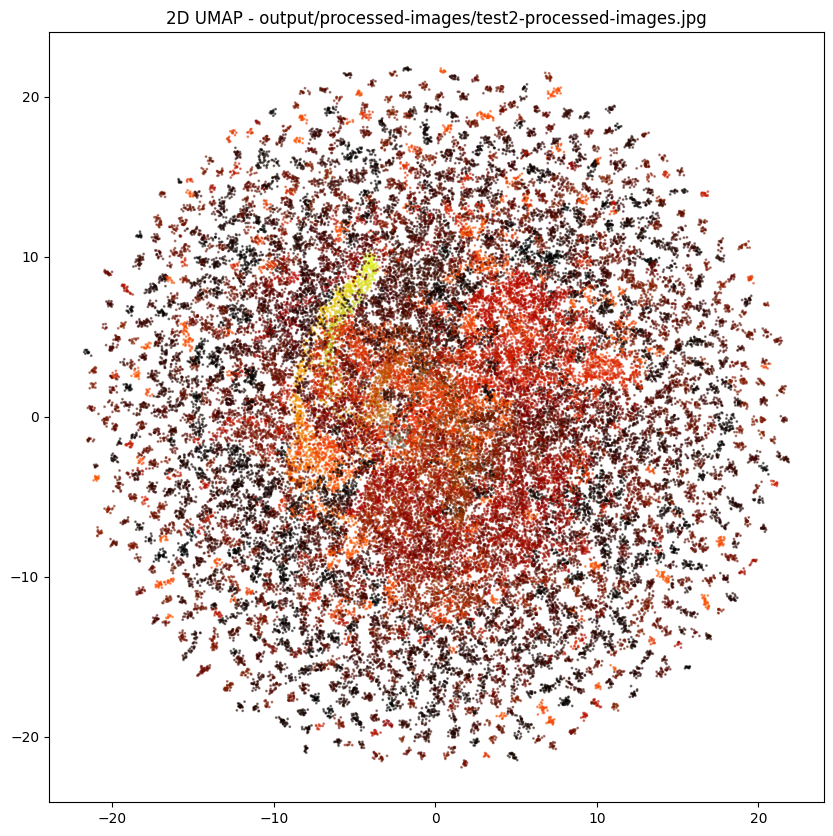

{'2d': {'embedding': array([[ -7.5902753,  15.477657 ],
       [  3.6793344,   5.735635 ],
       [ -1.5294791,  12.0807   ],
       ...,
       [  5.6227264,  10.211921 ],
       [-17.268145 ,  -8.941502 ],
       [-13.385586 ,   5.732437 ]], dtype=float32), 'pixel_data': array([[1.29000000e+02, 3.20000000e+01, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00],
       [1.33000000e+02, 2.90000000e+01, 2.00000000e+00, 3.33333333e-03,
        0.00000000e+00],
       [4.80000000e+01, 3.00000000e+00, 0.00000000e+00, 6.66666667e-03,
        0.00000000e+00],
       ...,
       [1.00000000e+00, 1.00000000e+00, 3.00000000e+00, 9.90000000e-01,
        9.95000000e-01],
       [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 9.93333333e-01,
        9.95000000e-01],
       [2.00000000e+00, 0.00000000e+00, 1.00000000e+00, 9.96666667e-01,
        9.95000000e-01]])}}


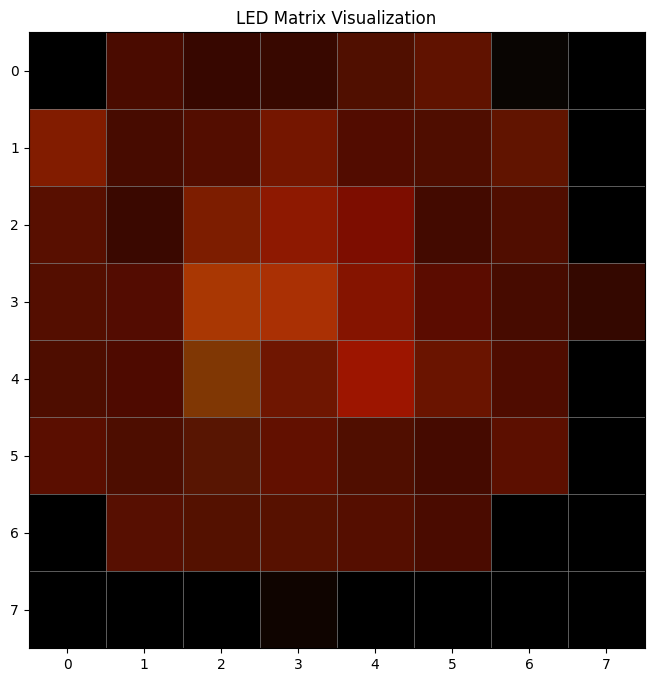

LED matrix visualization saved to: output/led-matrix/test2-led-matrix.png
UMAP data header file generated at: output/umap-data/test2-umap_data.h
{'matrix_size': 8, 'data': [[[0, 0, 0], [74, 11, 0], [55, 7, 0], [56, 8, 0], [80, 15, 0], [96, 18, 0], [9, 5, 2], [0, 0, 0]], [[130, 28, 0], [71, 11, 0], [83, 13, 0], [117, 22, 0], [82, 12, 0], [79, 13, 0], [97, 20, 0], [0, 0, 0]], [[88, 15, 0], [58, 8, 0], [125, 29, 0], [142, 25, 1], [125, 13, 0], [67, 10, 0], [80, 13, 0], [0, 0, 0]], [[84, 14, 0], [83, 12, 1], [169, 55, 3], [170, 48, 4], [133, 20, 0], [91, 12, 0], [71, 11, 0], [52, 8, 0]], [[78, 13, 0], [78, 10, 0], [128, 55, 4], [111, 22, 1], [157, 21, 0], [106, 20, 0], [79, 12, 0], [0, 0, 0]], [[90, 14, 0], [77, 13, 0], [88, 21, 2], [98, 16, 0], [80, 14, 0], [69, 10, 0], [92, 15, 0], [0, 0, 0]], [[0, 0, 0], [87, 15, 1], [84, 17, 0], [87, 17, 0], [85, 14, 0], [74, 11, 0], [0, 0, 0], [0, 0, 0]], [[0, 0, 0], [0, 0, 0], [0, 0, 0], [15, 4, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0]]], 'brig

In [7]:
# Example usage
image_processor = ImageProcessor(config=Config.CONFIG)
image_path = 'test2.jpg'  # Replace with the actual image file name
result = image_processor.process_image(image_path)
pixel_data = result['pixel_data']
original_filename = result['original_filename']

print(result)

# Example usage
umap_processor = UMAPProcessor()
result = umap_processor.process(result['pixel_data'], result['processed_path'])
umap_data = result['2d']['embedding']  # Get the UMAP embeddings
umap_pixel_data = result['2d']['pixel_data']  # Get the pixel data
print(result)

# Example usage (outside the class)
# Create LED Matrix processor
led_processor = LEDMatrix()

# Convert UMAP to LED matrix
led_matrix = led_processor.umap_to_matrix(umap_data, umap_pixel_data)

# Display the matrix
led_processor.display_matrix(led_matrix)

# Save both visualization and Arduino header
led_processor.save_matrix(led_matrix, "led_visualization", original_filename)
led_processor.save_arduino_header(led_matrix, original_filename)

# Get hardware-friendly matrix data
matrix_data = led_processor.get_matrix_data(led_matrix)
print(matrix_data)